## Setup: import libraries and functions

In [1]:
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import matplotlib.pyplot as plt
import gsw_xarray
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

APIKEY   = 'guest'
APIROOT  = 'https://argovis-api.colorado.edu/'

## Setup: configuration

Uncomment one collection block below. All cells in the notebook read from these variables — nothing else needs to be changed.

In [2]:
# ── Query ─────────────────────────────────────────────────────────────────────
START_DATE = '2010-01-01T00:00:00Z'
END_DATE   = '2024-12-31T00:00:00Z'
BOX        = [[-150, 45], [-145, 50]]

# ── Point-selection indices (used by single-point and section plots) ──────────
# Change these integers to select a different grid point or snapshot.
# After loading data the actual coordinate values are printed for reference.
ITIMESTAMP = 0   # index along the time axis
ILON       = 2   # index along the longitude axis
ILAT       = 2   # index along the latitude axis
ILEVEL     = 0   # index along the pressure-level axis (levelled collections only)

# ── Level index for all averaged / time-series plots ─────────────────────────
# Used wherever a single level must be chosen for an aggregated plot
# (e.g. horizontally averaged time-series). Change this one value to shift
# every such plot to a different depth without hunting through the notebook.
LEVEL = 0        # 0 = surface level

# ── Depth range for Hovmöller / area-weighted time-series plots ───────────────
# Shown as [min_dbar, max_dbar] on the y-axis. Change to zoom in on a layer.
YLIM = [0, 250]

# ── Collection (uncomment one block at a time) ────────────────────────────────

COLLECTION = 'grids/rg09'
VARIABLES  = ['rg09_temperature', 'rg09_salinity']
HAS_LEVELS = True
TEMP_VAR   = 'rg09_temperature'
SALT_VAR   = 'rg09_salinity'

# COLLECTION = 'grids/localGPintegral'
# VARIABLES  = ['potential_temperature']
# HAS_LEVELS = True
# TEMP_VAR   = None
# SALT_VAR   = None

# COLLECTION = 'timeseries/noaasst'
# VARIABLES  = ['sst']
# HAS_LEVELS = False
# TEMP_VAR   = None
# SALT_VAR   = None

# COLLECTION = 'timeseries/copernicussla'
# VARIABLES  = ['sla']
# HAS_LEVELS = False
# TEMP_VAR   = None
# SALT_VAR   = None

# COLLECTION = 'timeseries/ccmpwind'
# VARIABLES  = ['ws']
# HAS_LEVELS = False
# TEMP_VAR   = None
# SALT_VAR   = None

# ── GLODAP ────────────────────────────────────────────────────────────────────
# GLODAP (Global Ocean Data Analysis Project) is a climatological gridded
# product derived from bottle data collected over decades of oceanographic
# cruises.  Unlike time-varying products such as RG09, it represents a single
# climatological estimate.  Argovis indexes it with a fixed timestamp
# (1000-01-01), so START_DATE / END_DATE must be set to those fixed values
# regardless of the region — this is not a bug.
#
# For the plots below:
#   • Single-point time-series and Hovmöller plots will show only one point
#     (not very informative, but they will run without errors).
#   • Deseasonalized anomalies will be identically zero by construction,
#     because groupby('timestamp.month') sees only one month group.
#     This is expected and reflects the nature of a climatology.
#
# COLLECTION = 'grids/glodap'
# VARIABLES  = ['temperature', 'salinity']
# HAS_LEVELS = True
# TEMP_VAR   = 'temperature'
# SALT_VAR   = 'salinity'
# START_DATE = '1000-01-01T00:00:00Z'
# END_DATE   = '1000-01-01T00:00:01Z'

## Load data

Query the selected collection via the Argovis API. Depending on the region and time period this may take a moment.

In [3]:
options = {
    'startDate': START_DATE,
    'endDate'  : END_DATE,
    'box'      : BOX,
    'data'     : ','.join(VARIABLES),
}

grid_raw = avh.queryGrid(COLLECTION, options=options, apikey=APIKEY, apiroot=APIROOT)
print(f"Loaded: {list(grid_raw.data_vars)}")
grid_raw  

Loaded: ['rg09_salinity', 'rg09_temperature']


<xarray.Dataset>
Dimensions:           (timestamp: 180, longitude: 5, latitude: 5, level: 58)
Coordinates:
  * timestamp         (timestamp) datetime64[ns] 2010-01-15 ... 2024-12-15
  * longitude         (longitude) float64 -149.5 -148.5 -147.5 -146.5 -145.5
  * latitude          (latitude) float64 45.5 46.5 47.5 48.5 49.5
  * level             (level) float64 2.5 10.0 20.0 ... 1.9e+03 1.975e+03
Data variables:
    rg09_salinity     (timestamp, longitude, latitude, level) float64 32.78 ....
    rg09_temperature  (timestamp, longitude, latitude, level) float64 8.088 ....

In [4]:
# Create selected coordinate values (for use in plot titles)
sel_timestamp = str(grid_raw.timestamp.values[ITIMESTAMP])[:10] 
sel_lon       = float(grid_raw.longitude.values[ILON])
sel_lat       = float(grid_raw.latitude.values[ILAT])
if HAS_LEVELS:
    sel_level        = float(grid_raw.level.values[ILEVEL])
    level_is_numeric = np.issubdtype(grid_raw.level.values.dtype, np.number)
    level_has_depth  = len(grid_raw.level) > 1
else:
    sel_level        = None
    level_is_numeric = False
    level_has_depth  = False

print(f"Selected point — timestamp: {sel_timestamp}, "
      f"lon: {sel_lon:.1f}, lat: {sel_lat:.1f}"
      + (f", level: {sel_level:.0f} dbar" if sel_level is not None else ""))

if HAS_LEVELS and (not level_is_numeric or not level_has_depth):
    print(f"Note: level coordinate is not a numeric multi-level depth axis "
          f"(values: {list(grid_raw.level.values)}). "
          f"Profile, section, and Hovmöller plots will be skipped.")

Selected point — timestamp: 2010-01-15, lon: -147.5, lat: 47.5, level: 2 dbar


### Example of subset in space

Commented out by default — it shows how to subset the dataset to a sub-region before plotting.

In [5]:
# subset = grid_raw.sel(
#     latitude=slice(42.5, 46.5),
#     longitude=slice(-154.5, -150.5)
# )
#
# for var in VARIABLES:
#     fig, ax = plt.subplots()
#     if 'level' in grid_raw[var].dims:
#         # Leveled variable: show a single-point depth profile
#         subset[var].isel(timestamp=0, longitude=0, latitude=0).plot(y='level', ax=ax)
#         ax.invert_yaxis()
#         ax.set_title(f'{var} — single-point profile (subset)')
#     else:
#         # 2-D / surface variable: show a map snapshot
#         subset[var].isel(timestamp=0).plot(x='longitude', y='latitude', ax=ax)
#         ax.set_title(f'{var} — map snapshot (subset)')
#     plt.tight_layout()
#     plt.show()
#     plt.close()

## Visualization
### Single-point profile (variable vs depth)

Only runs for collections with a `level` dimension.

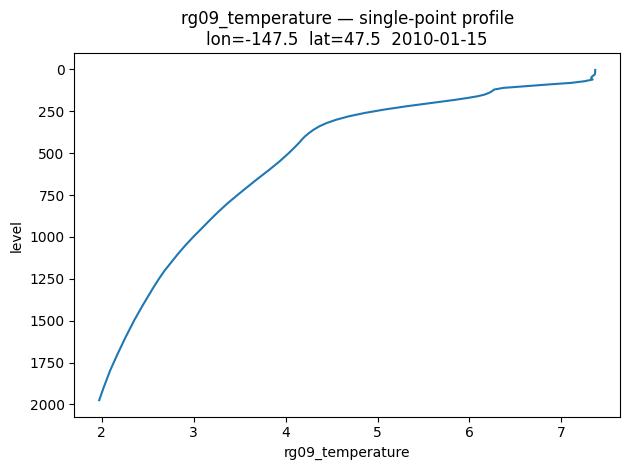

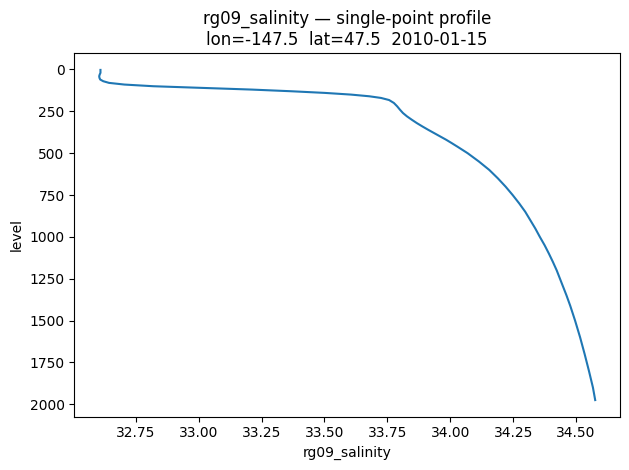

In [6]:
if HAS_LEVELS and level_is_numeric and level_has_depth:
    for var in VARIABLES:
        fig, ax = plt.subplots()
        data = grid_raw[var].isel(timestamp=ITIMESTAMP, longitude=ILON, latitude=ILAT)
        ax.plot(data.values, data.level)
        ax.invert_yaxis()
        ax.set_xlabel(var)
        ax.set_ylabel('level')
        ax.set_title(f'{var} — single-point profile\n'
                     f'lon={sel_lon:.1f}  lat={sel_lat:.1f}  {sel_timestamp}')
        plt.tight_layout()
        plt.show()
        plt.close()
elif HAS_LEVELS:
    print("Skipping single-point profile — requires a numeric multi-level depth axis.")
else:
    print("Skipping single-point profile — not applicable for collections without a level dimension.")

## Visualization
### Map snapshot

Variable values at a fixed timestamp (and level, for collections with levels).

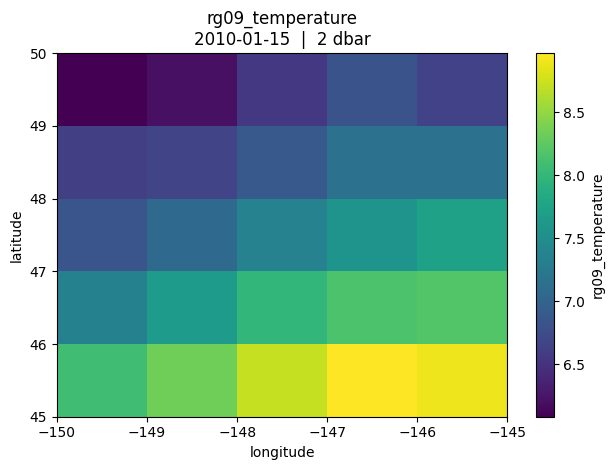

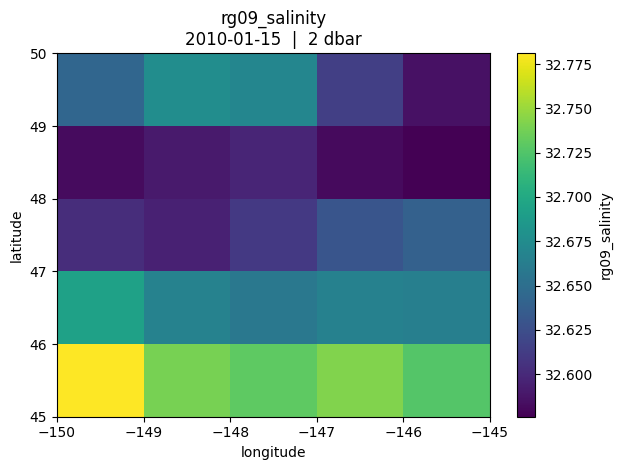

In [7]:
for var in VARIABLES:
    fig, ax = plt.subplots()
    if HAS_LEVELS:
        da = grid_raw[var].isel(timestamp=ITIMESTAMP, level=ILEVEL)
        level_val = float(da.level.values)
        da.plot(x='longitude', y='latitude', ax=ax)
        ax.set_title(f'{var}\n{sel_timestamp}  |  {level_val:.0f} dbar')
    else:
        grid_raw[var].isel(timestamp=ITIMESTAMP).plot(x='longitude', y='latitude', ax=ax)
        ax.set_title(f'{var} — {sel_timestamp}')
    plt.tight_layout()
    plt.show()
    plt.close()

## Visualization
### Time-series at a single grid point


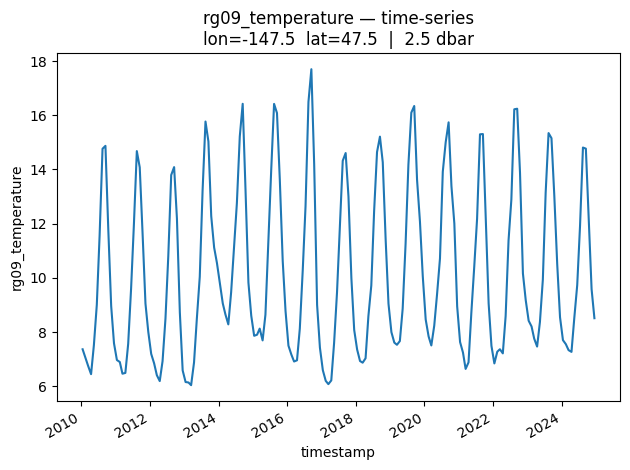

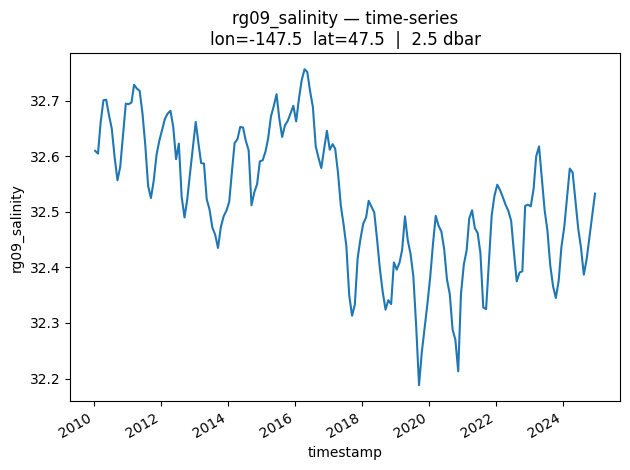

In [8]:
if len(grid_raw.timestamp) < 2:
    print("Skipping single-point time-series — only one timestamp available (e.g. GLODAP).")
else:
    for var in VARIABLES:
        fig, ax = plt.subplots()
        da = grid_raw[var].isel(latitude=ILAT, longitude=ILON)
        if HAS_LEVELS:
            da = da.isel(level=ILEVEL)
            level_val = float(da.level.values)
            da.plot(ax=ax)
            ax.set_title(f'{var} — time-series\n'
                         f'lon={sel_lon:.1f}  lat={sel_lat:.1f}  |  {level_val:.1f} dbar')
        else:
            da.plot(ax=ax)
            ax.set_title(f'{var} — time-series\nlon={sel_lon:.1f}  lat={sel_lat:.1f}')
        plt.tight_layout()
        plt.show()
        plt.close()

## Visualization
### Section — fixed longitude

Only runs for collections with a `level` dimension.

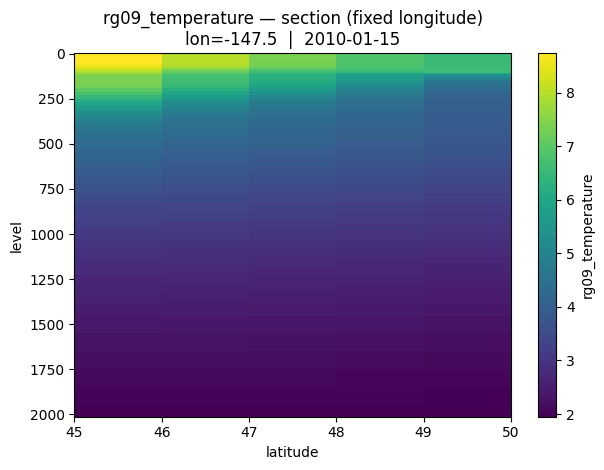

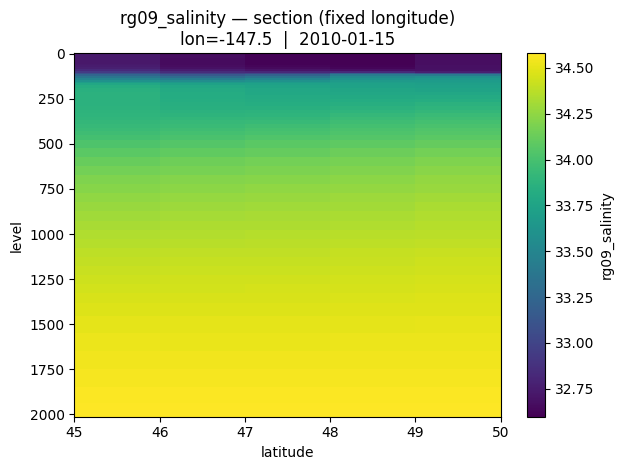

In [9]:
if HAS_LEVELS and level_is_numeric and level_has_depth:
    for var in VARIABLES:
        fig, ax = plt.subplots()
        grid_raw[var].isel(longitude=ILON, timestamp=ITIMESTAMP).plot(x='latitude', y='level', ax=ax)
        ax.invert_yaxis()
        ax.set_title(f'{var} — section (fixed longitude)\n'
                     f'lon={sel_lon:.1f}  |  {sel_timestamp}')
        plt.tight_layout()
        plt.show()
        plt.close()
elif HAS_LEVELS:
    print("Skipping fixed-longitude section — requires a numeric multi-level depth axis.")
else:
    print("Skipping fixed-longitude section — not applicable for collections without a level dimension.")

## Visualization
### Section — fixed latitude

Only runs for collections with a `level` dimension.

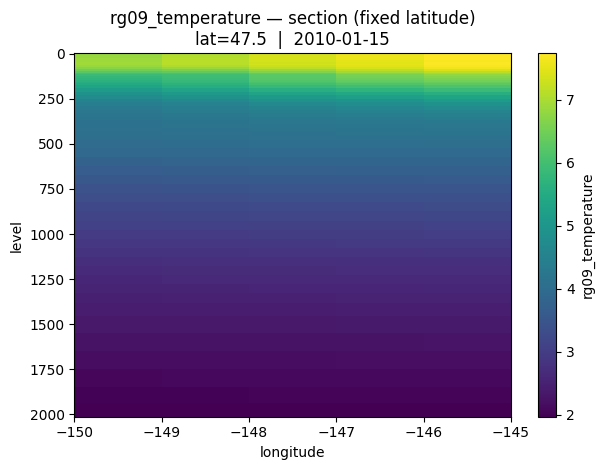

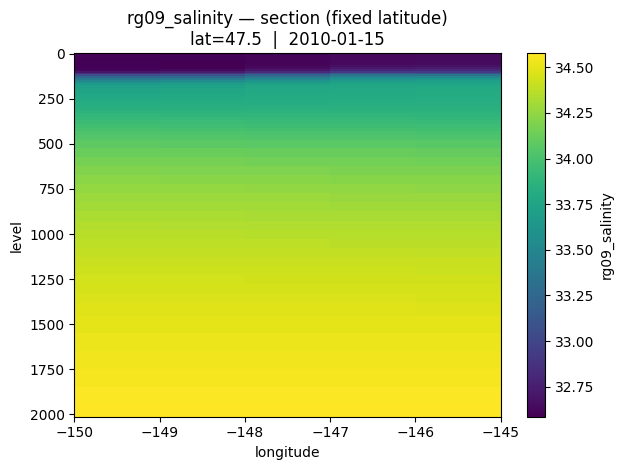

In [10]:
if HAS_LEVELS and level_is_numeric and level_has_depth:
    for var in VARIABLES:
        fig, ax = plt.subplots()
        grid_raw[var].isel(latitude=ILAT, timestamp=ITIMESTAMP).plot(x='longitude', y='level', ax=ax)
        ax.invert_yaxis()
        ax.set_title(f'{var} — section (fixed latitude)\n'
                     f'lat={sel_lat:.1f}  |  {sel_timestamp}')
        plt.tight_layout()
        plt.show()
        plt.close()
elif HAS_LEVELS:
    print("Skipping fixed-longitude section — requires a numeric multi-level depth axis.")
else:
    print("Skipping fixed-longitude section — not applicable for collections without a level dimension.")

## Visualization
### Hovmöller — single grid point (time vs depth)

Only runs for collections with a `level` dimension and more than one timestamp.

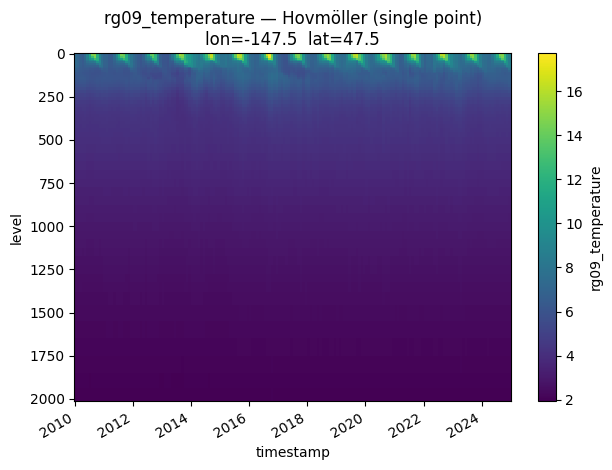

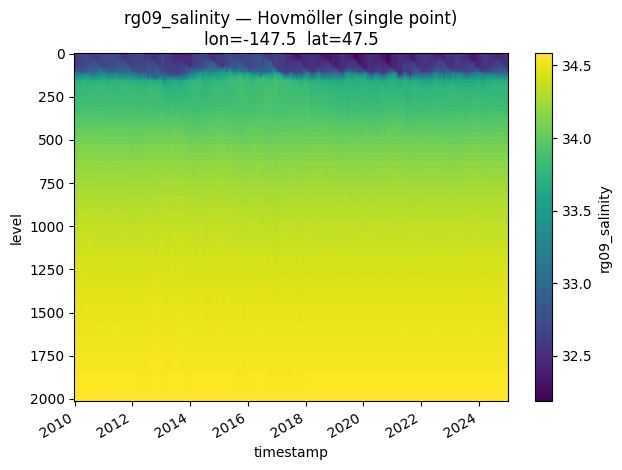

In [11]:
if HAS_LEVELS and level_is_numeric and level_has_depth and len(grid_raw.timestamp) > 1:
    for var in VARIABLES:
        fig, ax = plt.subplots()
        grid_raw[var].isel(latitude=ILAT, longitude=ILON).plot(x='timestamp', y='level', ax=ax)
        ax.invert_yaxis()
        ax.set_title(f'{var} — Hovmöller (single point)\n'
                     f'lon={sel_lon:.1f}  lat={sel_lat:.1f}')
        plt.tight_layout()
        plt.show()
        plt.close()
elif HAS_LEVELS and level_is_numeric and level_has_depth:
    print("Skipping Hovmöller — requires more than one timestamp.")
elif HAS_LEVELS:
    print("Skipping Hovmöller — requires a numeric multi-level depth axis.")
else:
    print("Skipping Hovmöller — not applicable for collections without a level dimension.")

## Derived quantities
### GSW: absolute salinity, conservative temperature, potential density (σ₀)

Only runs when both `TEMP_VAR` and `SALT_VAR` are set and present in the dataset.

In [12]:
# Requires both TEMP_VAR and SALT_VAR to be set and present in the dataset
if TEMP_VAR and SALT_VAR and TEMP_VAR in grid_raw and SALT_VAR in grid_raw:
    SA     = gsw_xarray.SA_from_SP(SP=grid_raw[SALT_VAR], p=grid_raw.level,
                                    lon=grid_raw.longitude, lat=grid_raw.latitude)
    CT     = gsw_xarray.CT_from_t(SA=SA, t=grid_raw[TEMP_VAR], p=grid_raw.level)
    sigma0 = gsw_xarray.sigma0(SA, CT) + 1000

    grid_raw = grid_raw.assign({
        'absolute_salinity'       : SA,
        'conservative_temperature': CT,
        'sigma0'                  : sigma0,
    })
    print("GSW quantities computed: absolute_salinity, conservative_temperature, sigma0")
else:
    print("Skipping GSW — TEMP_VAR and/or SALT_VAR not available.")

GSW quantities computed: absolute_salinity, conservative_temperature, sigma0


### Mixed layer depth (MLD)

Estimated from the potential density profile using a threshold criterion (Δσ₀ = 0.03 kg/m³ relative to 10 dbar). Only runs when σ₀ was successfully computed above.

In [13]:
if 'sigma0' in grid_raw:
    pressure = grid_raw.level.values
    sigma0_v = grid_raw['sigma0'].values   # (timestamp, longitude, latitude, level)
    shape    = sigma0_v.shape[:3]
    mld      = np.full(shape, np.nan)

    for t in range(shape[0]):
        for lo in range(shape[1]):
            for la in range(shape[2]):
                result = ava.MLD_estimate(
                    pressure=pressure,
                    var=sigma0_v[t, lo, la, :],
                    threshold_delta=0.03,
                    reference_pressure=10
                )[0]
                mld[t, lo, la] = result if result is not None else np.nan

    mld_da = xr.DataArray(
        mld,
        coords={'timestamp': grid_raw.timestamp,
                'longitude': grid_raw.longitude,
                'latitude' : grid_raw.latitude},
        dims=['timestamp', 'longitude', 'latitude'],
        name='MLD'
    )
    grid_raw = grid_raw.assign({'MLD': mld_da})
    print("MLD computed.")
else:
    print("Skipping MLD — sigma0 not available.")

MLD computed.


## Visualization
### Time average of the area-weighted horizontal mean profile

Only runs for collections with a `level` dimension.

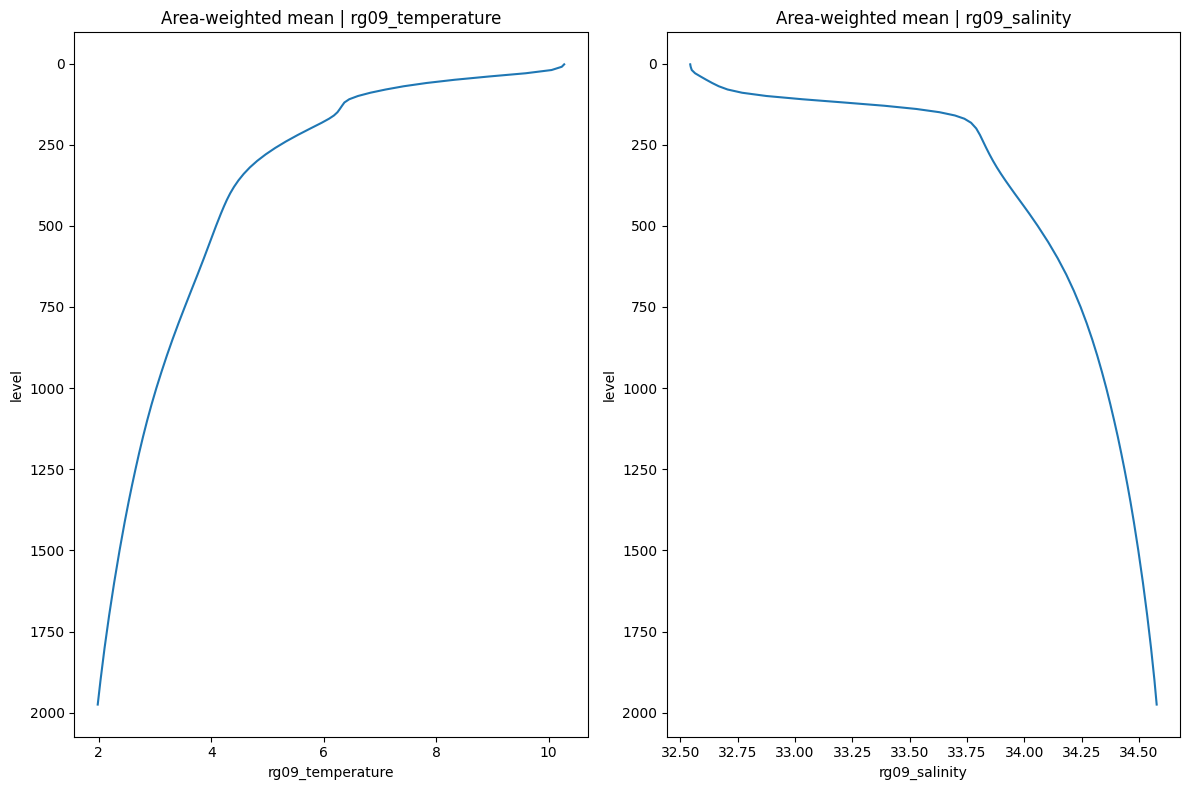

In [14]:
if HAS_LEVELS and level_is_numeric and level_has_depth:
    vars_with_levels = [v for v in VARIABLES if 'level' in grid_raw[v].dims]
    n   = len(vars_with_levels)
    awm = ava.regional_mean(grid_raw, form='area').mean(dim='timestamp')

    fig, axes = plt.subplots(1, n, figsize=(6*n, 8))
    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, vars_with_levels):
        awm[var].plot(y='level', ax=ax)
        ax.invert_yaxis()
        ax.set_title(f'Area-weighted mean | {var}')

    plt.tight_layout()
    plt.show()
    plt.close()
elif HAS_LEVELS:
    print("Skipping horizontally averaged profile — requires a numeric multi-level depth axis.")
else:
    print("Skipping horizontally averaged profile — not applicable for collections without a level dimension.")

## Visualization
### Horizontally averaged time-series

Area-weighted mean over the region for every variable (and MLD if computed). For levelled variables, the level selected by LEVEL is used. Change VARIABLES_to_plot to restrict or reorder the panels.

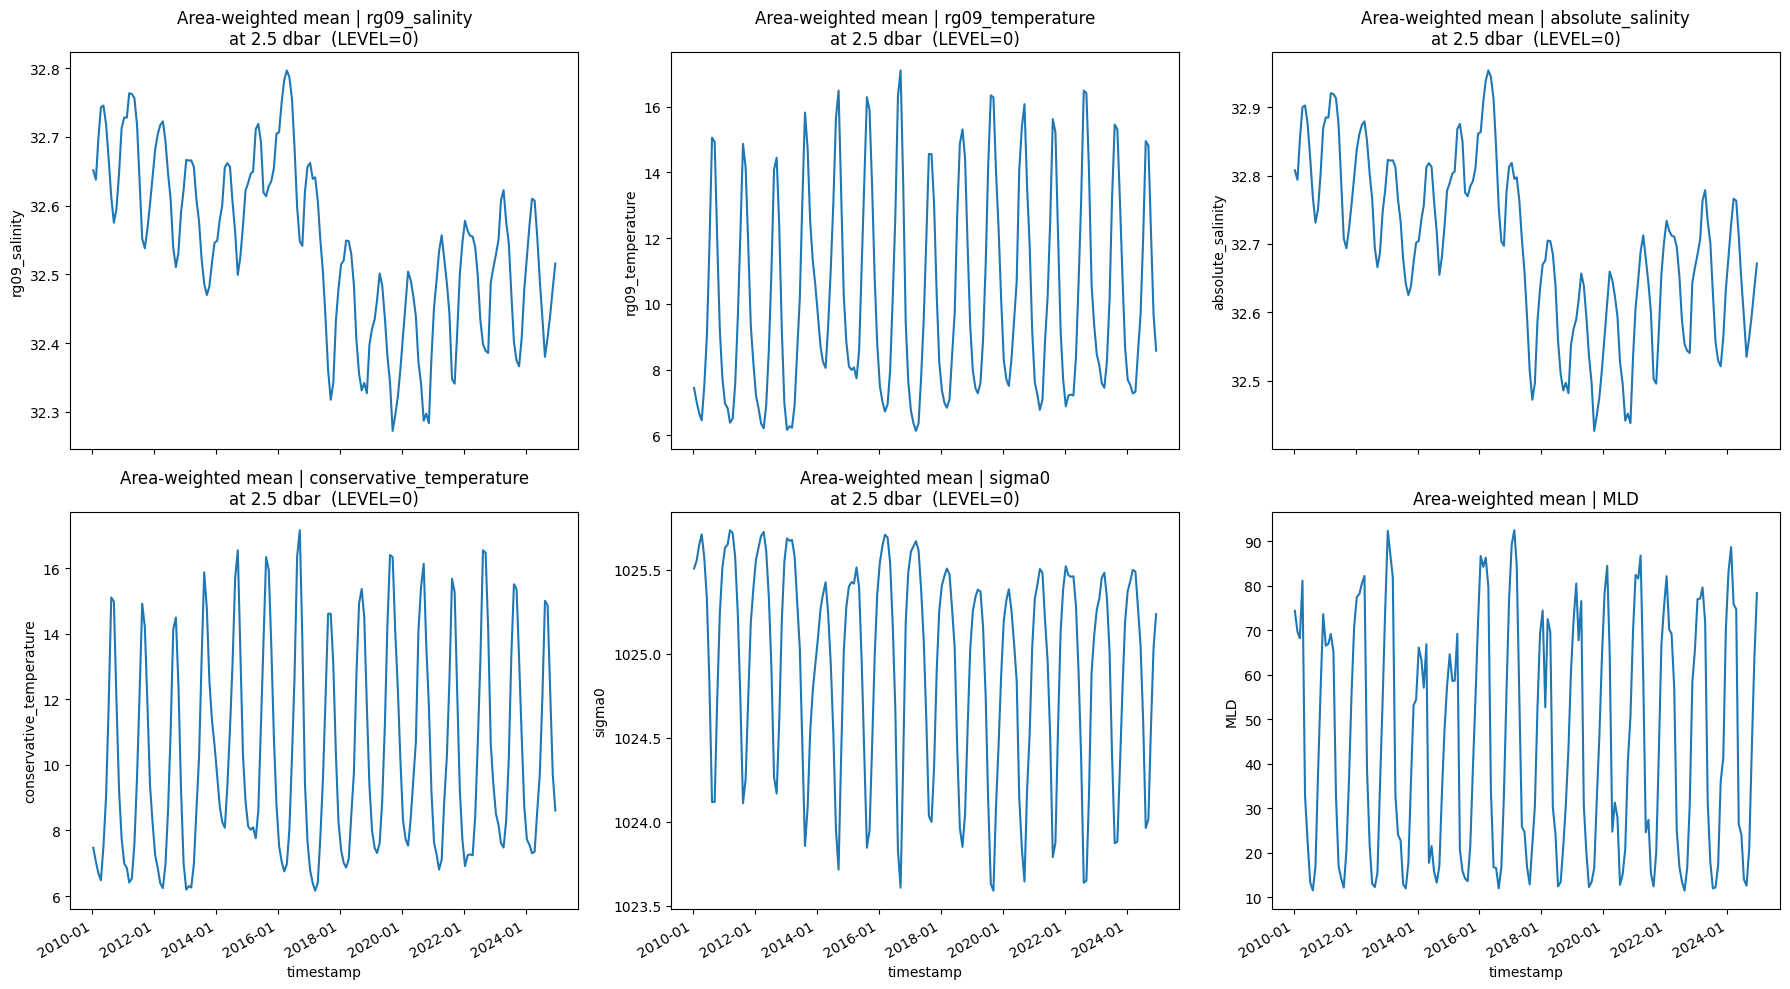

In [15]:
awm = ava.regional_mean(grid_raw, form='area')

# All keys present in awm — change this list to plot only a subset or to reorder.
VARIABLES_to_plot = list(awm.data_vars)

if len(grid_raw.timestamp) < 2:
    print("Skipping horizontally averaged time-series — only one timestamp available (e.g. GLODAP).")
else:
    n_cols = 3
    n_rows = max(1, (len(VARIABLES_to_plot) + n_cols - 1) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)

    for idx, var in enumerate(VARIABLES_to_plot):
        ax = axes[idx // n_cols][idx % n_cols]
        da = awm[var]
        if 'level' in da.dims:
            da = da.isel(level=LEVEL)
            level_val = float(da.level.values)
            da.plot(x='timestamp', ax=ax)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax.set_title(f'Area-weighted mean | {var}\nat {level_val:.1f} dbar  (LEVEL={LEVEL})')
        else:
            da.plot(x='timestamp', ax=ax)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax.set_title(f'Area-weighted mean | {var}')

    for idx in range(len(VARIABLES_to_plot), n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
    plt.close()

## Visualization
### Area-weighted time-series: raw, climatology, and anomalies

For multi-timestamp collections: Hovmöller diagrams (time × depth) of the
area-weighted mean for each levelled variable. `YLIM` sets the depth range
displayed on the y-axis — adjust it to zoom in on a particular layer.

For single-timestamp collections (e.g. GLODAP): vertical profiles are shown instead. 
Deseasonalized anomalies are zero by construction — this is expected
and reflects the nature of a single-estimate climatology.

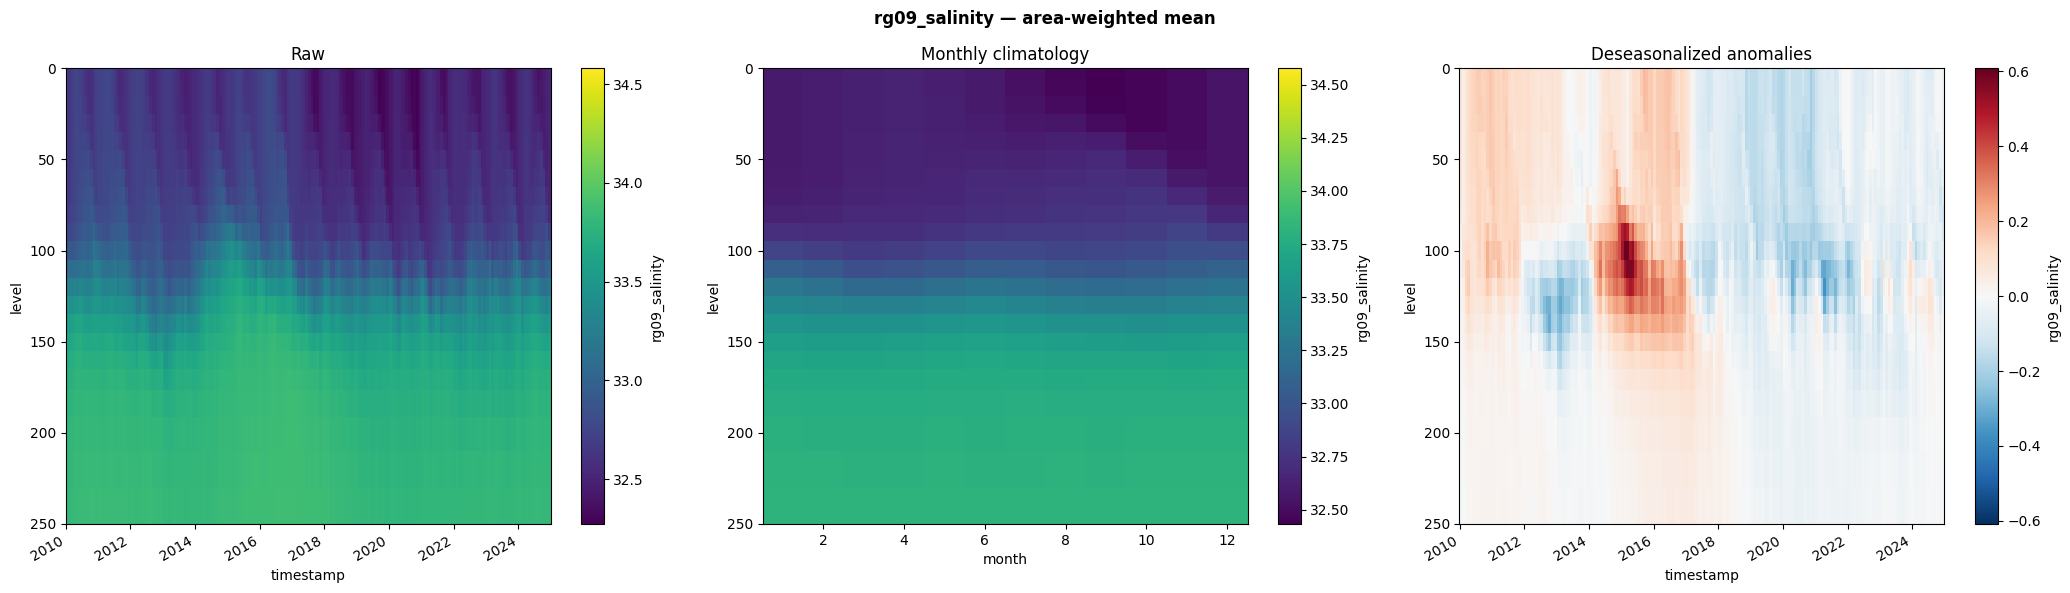

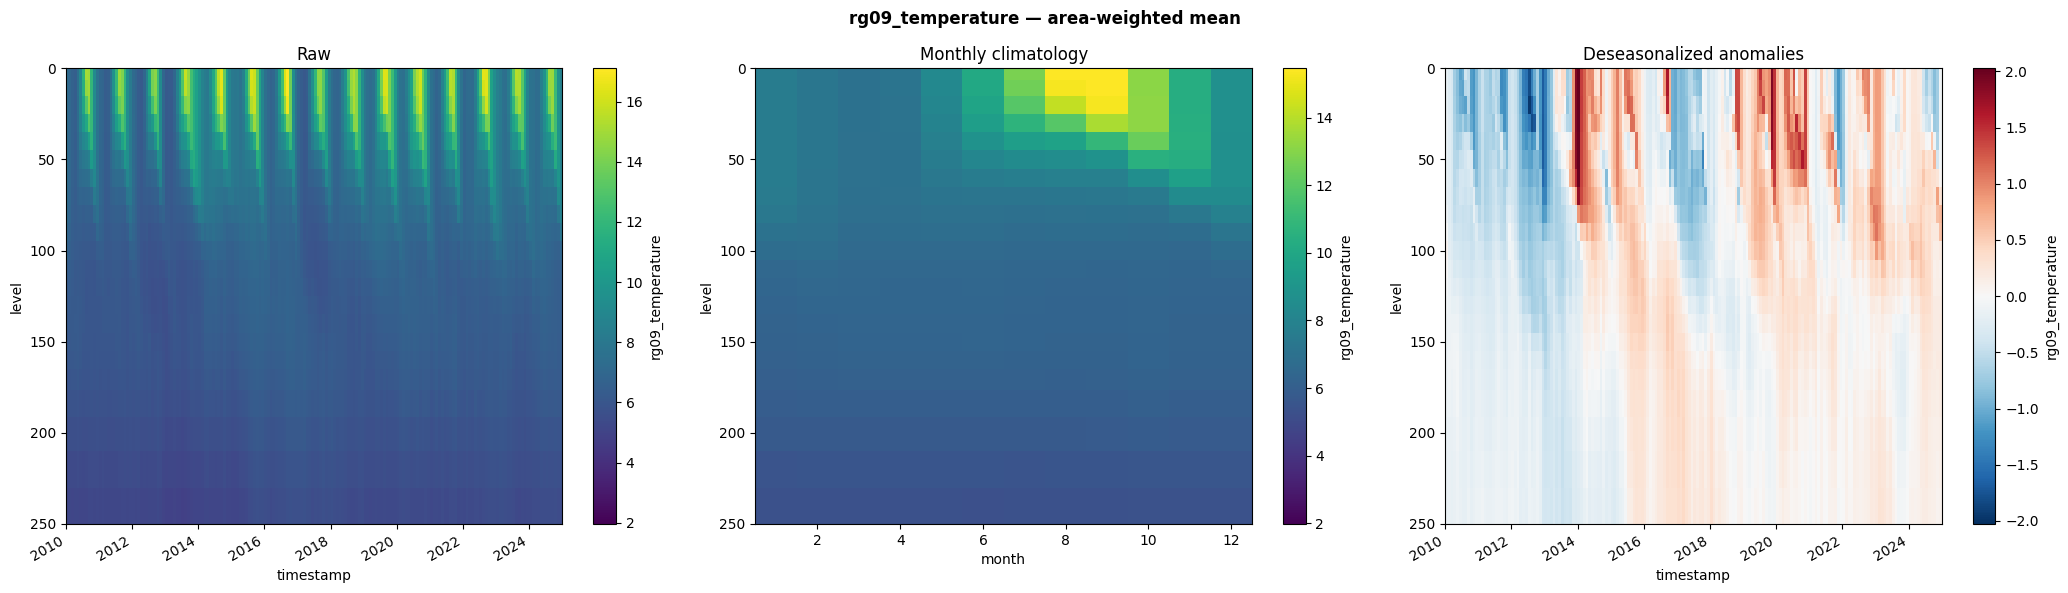

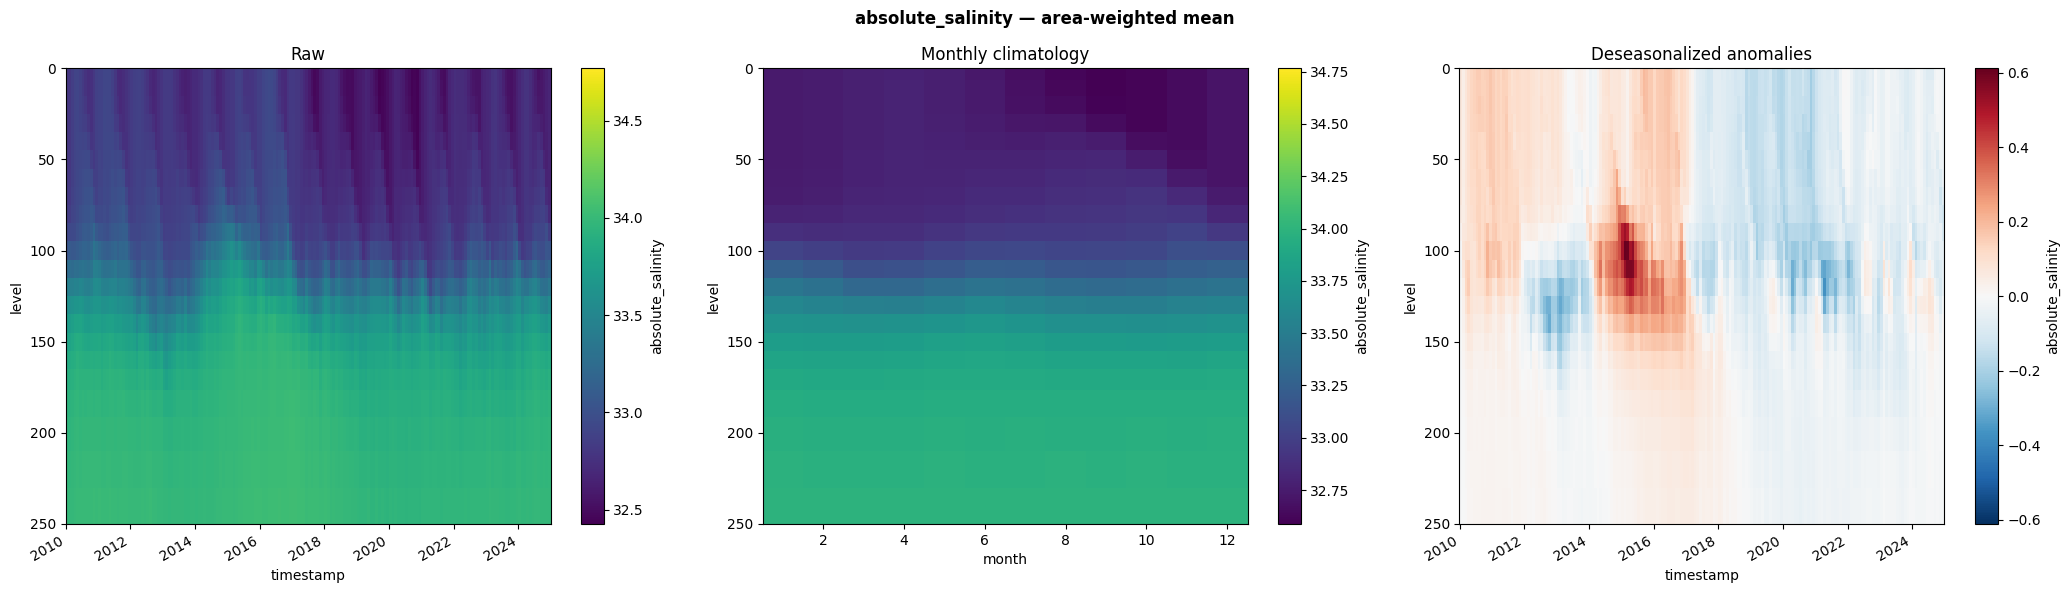

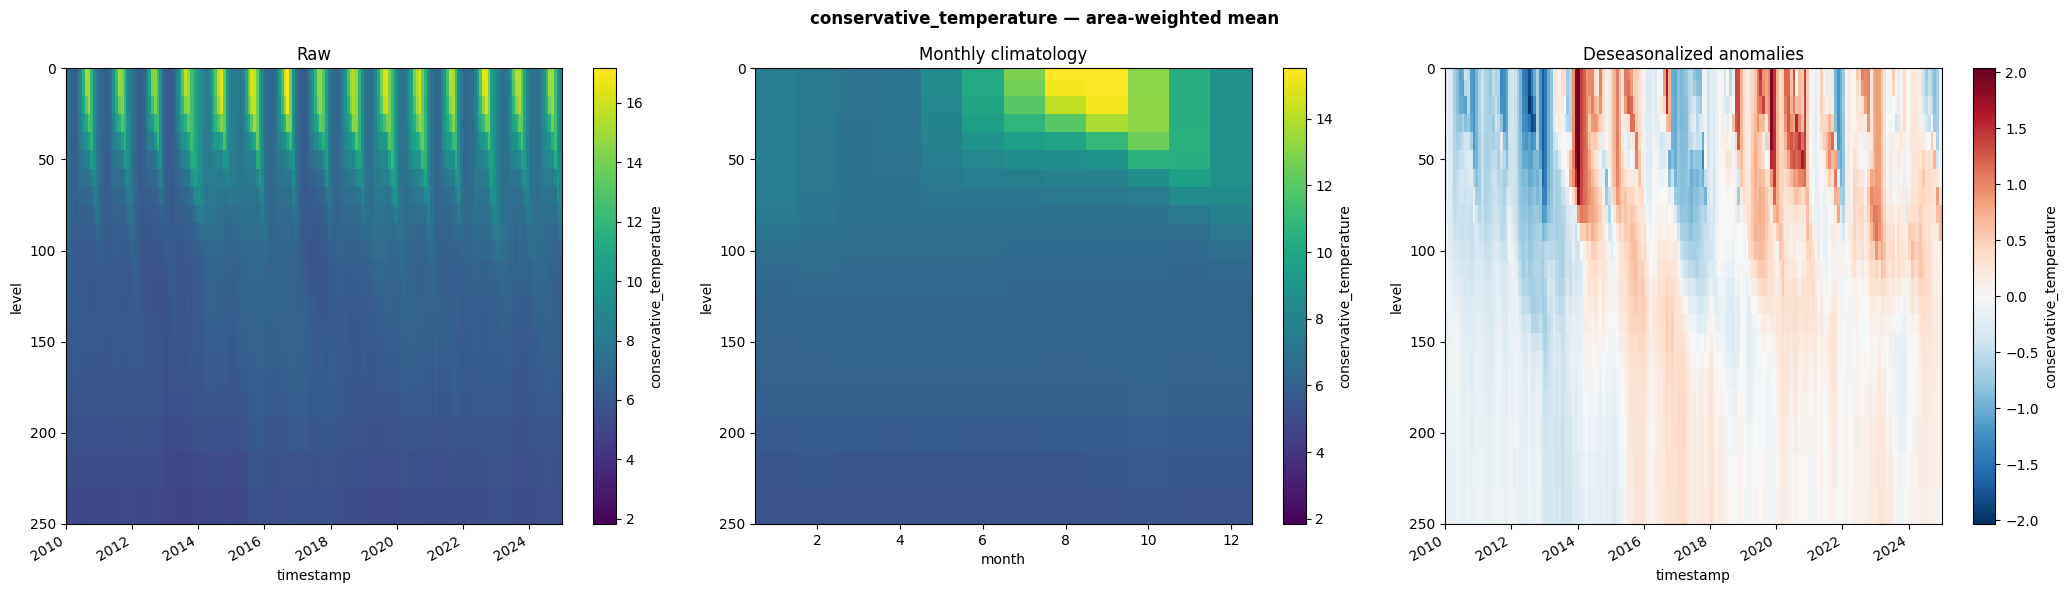

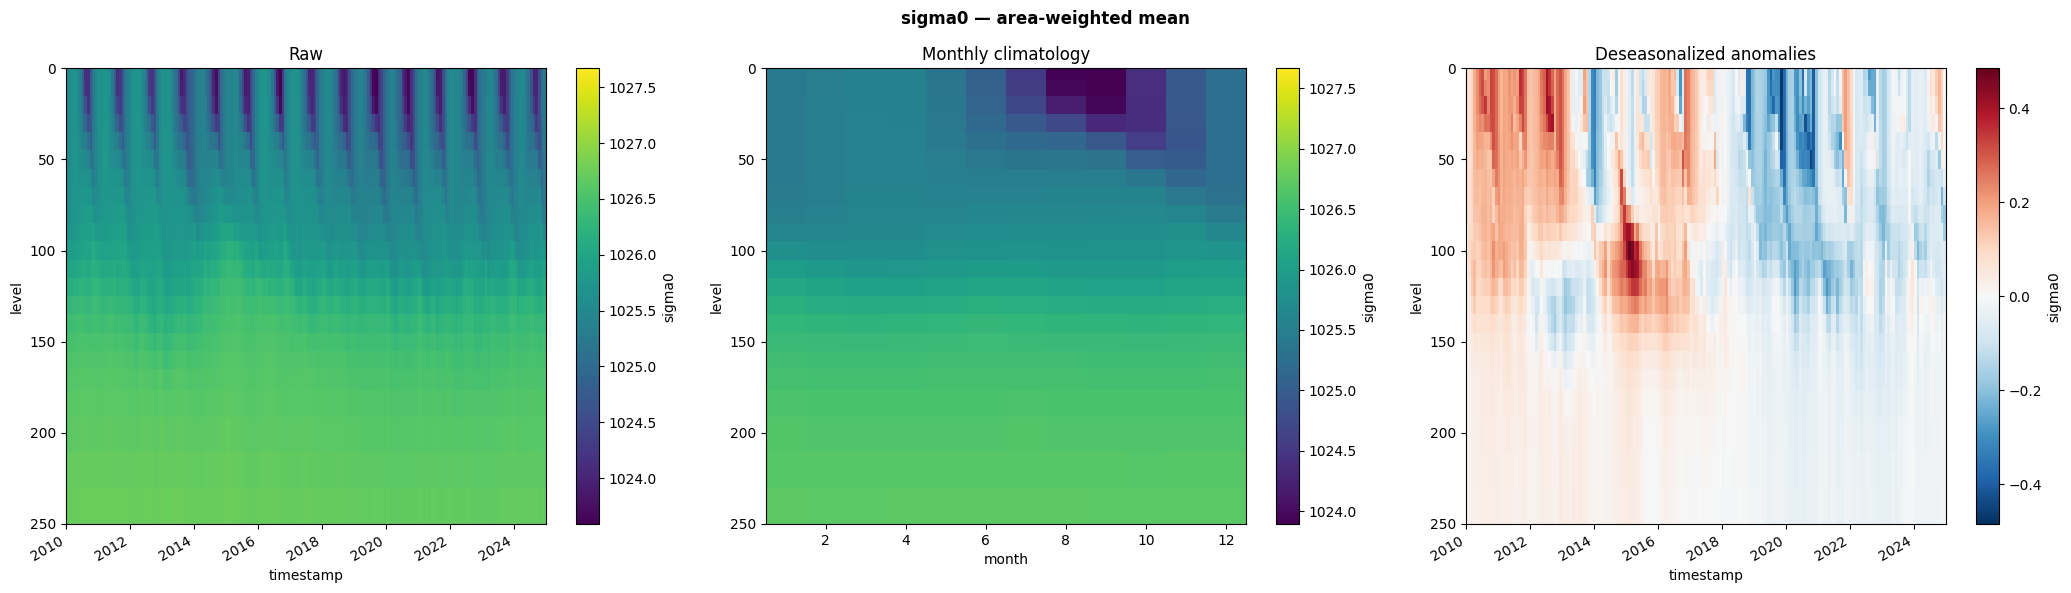

In [16]:
if HAS_LEVELS and level_is_numeric and level_has_depth:
    awm = ava.regional_mean(grid_raw, form='area')
    vars_with_levels = [v for v in VARIABLES_to_plot if 'level' in grid_raw[v].dims]

    for var in vars_with_levels:
        da = awm[var]
        fig, axes = plt.subplots(1, 3, figsize=(21, 6))

        if len(grid_raw.timestamp) > 1:
            climatology = da.groupby('timestamp.month').mean('timestamp')
            anomalies   = da.groupby('timestamp.month') - climatology

            da.plot(x='timestamp', y='level', ax=axes[0], ylim=YLIM)
            axes[0].invert_yaxis()
            axes[0].set_title('Raw')

            climatology.transpose('level', 'month').plot(ax=axes[1], ylim=YLIM)
            axes[1].invert_yaxis()
            axes[1].set_title('Monthly climatology')

            anomalies.plot(x='timestamp', y='level', ax=axes[2], ylim=YLIM)
            axes[2].invert_yaxis()
            axes[2].set_title('Deseasonalized anomalies')
        else:
            climatology = da
            anomalies   = xr.zeros_like(da)

            da.squeeze('timestamp').plot(y='level', ax=axes[0], ylim=YLIM)
            axes[0].invert_yaxis()
            axes[0].set_title('Raw (climatological profile)')

            climatology.squeeze('timestamp').plot(y='level', ax=axes[1], ylim=YLIM)
            axes[1].invert_yaxis()
            axes[1].set_title('Monthly climatology')

            anomalies.squeeze('timestamp').plot(y='level', ax=axes[2], ylim=YLIM)
            axes[2].invert_yaxis()
            axes[2].set_title('Deseasonalized anomalies\n(zero by construction for climatological products)')

        fig.suptitle(f'{var} — area-weighted mean', fontweight='bold')
        fig.tight_layout()
        plt.show()
        plt.close()
elif HAS_LEVELS:
    print("Skipping area-weighted Hovmöller — requires a numeric multi-level depth axis.")
else:
    print("Skipping area-weighted Hovmöller — not applicable for collections without a level dimension.")
    